# Full legends in images — `save_png`, static images and `legend_scroll`

With many sets the legend outgrows the figure. On screen Plotly copes in two ways:
it **squeezes the plot** to make room for the legend, and once the legend passes
its height cap it adds a **scrollbar**. A saved image can't scroll, so it showed
only the part of the legend that fit, above a shrunken plot.

Now:

| Output | Legend | How to change it |
|---|---|---|
| `nb.save_png(...)` | always complete | — |
| static images (`nb.set_static_images()`) | always complete | — |
| interactive plots | scrolls, as before | `nb.set_default_format(legend_scroll=False)` shows it all |

When the legend needs more room, the **figure grows taller** and the **plot area
keeps its size**, so a plot with 40 sets has the same plot area as one with 3. A
legend that already fits leaves the figure exactly as it was.

Everything below uses synthetic data and writes its images to a temporary folder,
so it's safe to *Run All*.

## Setup

In [1]:
# --- make repo-root importable (notebook lives in demo_notebooks/) ---
import sys, os
_repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import contextlib, io, shutil, struct, tempfile
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, display
from unichart import UnichartNotebook

out_dir = Path(tempfile.mkdtemp(prefix='unichart_legend_demo_'))


def engine_runs(n_runs, n=40, seed=3):
    # One frame holding n_runs RPM sweeps; load_df splits it into sets by 'run'.
    rng = np.random.default_rng(seed)
    rpm = np.linspace(1000, 6000, n)
    return pd.concat([pd.DataFrame({
        'run': i,
        'title': f'Run {i:02d} — build {"ABC"[i % 3]}, ambient {15 + i}°C',
        'RPM': rpm,
        'Torque': 200 + 60 * np.sin(rpm / 1500 + i / 5) + rng.normal(0, 4, n),
        'EGT': 600 + 0.05 * rpm + 3 * i + rng.normal(0, 6, n),
    }) for i in range(n_runs)], ignore_index=True)


def notebook_with(n_runs):
    with contextlib.redirect_stdout(io.StringIO()):   # hush the per-set "Loaded Set" lines
        nb = UnichartNotebook()
        nb.set_copy_buttons(False)
        nb.load_df(engine_runs(n_runs), set_idx_column='run', set_name_column='title')
    return nb

### Two small helpers

`layout` reads the geometry back off a figure: its height, the top and bottom
margins, the **plot area** left between them, and the legend's height cap
(`None` means Plotly's default cap, past which the legend scrolls). `show_png`
prints an image's pixel size and displays it.

In [2]:
def layout(fig):
    L, m = fig.layout, fig.layout.margin
    top = 100 if m.t is None else m.t
    bottom = 80 if m.b is None else m.b
    height = L.height or 800
    return {'figure height': round(height),
            'top margin': round(top),
            'bottom margin': round(bottom),
            'plot area height': round(height - top - bottom),
            'legend cap': L.legend.maxheight}


def show_png(path, width=900):
    with open(path, 'rb') as f:
        w, h = struct.unpack('>II', f.read(24)[16:24])
    print(f'{path.name}: {w} x {h} px')
    display(Image(filename=str(path), width=width))

---
## 1. The problem: 40 sets

Forty runs, one legend entry each. The legend wraps to 14 rows. That's far more than
the room reserved above the plot, so Plotly shrinks the plot to fit the legend in.
It's also just past Plotly's height cap, so the legend gets a scrollbar: the last
entry is only reachable by scrolling.

In [3]:
nb = notebook_with(40)
nb.plot(x='RPM', y='Torque', suptitle='Torque sweep — 40 runs')

Exporting that figure exactly as it is, with Plotly's own `write_image`, shows what
an image looked like before. The plot is squashed under the legend, and the last
entry (Run 39) is missing, since an image can't scroll to it.

as_is.png: 1200 x 800 px


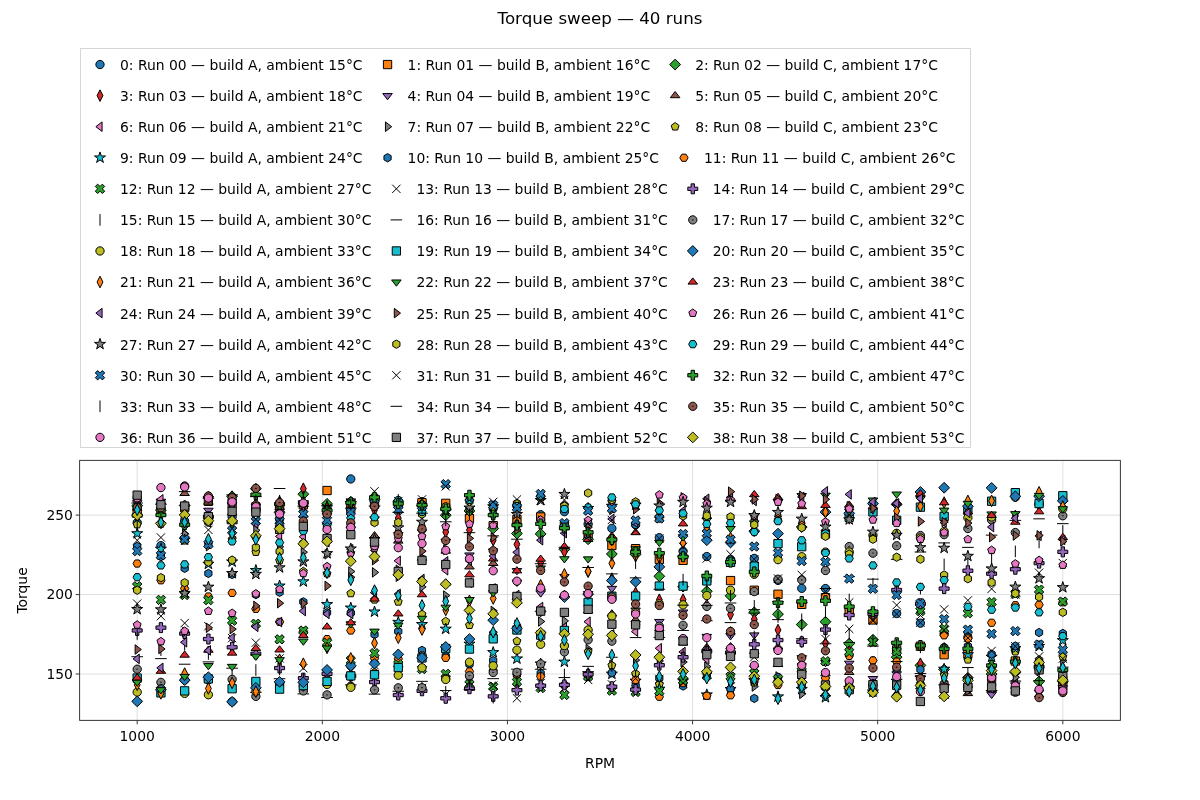

In [4]:
as_is = out_dir / 'as_is.png'
nb.last_fig.write_image(as_is, scale=1)    # Plotly's export, no legend fitting
show_png(as_is)

---
## 2. `save_png` shows the whole legend

`save_png` makes the image taller instead, so the legend gets its own space and the
plot keeps the size it would have with a one-row legend.

Plot saved to /tmp/unichart_legend_demo_36p0c5g0/full_legend.png (session embedded: 40 set(s) (0 file-referenced, 40 embedded))
full_legend.png: 1200 x 1222 px


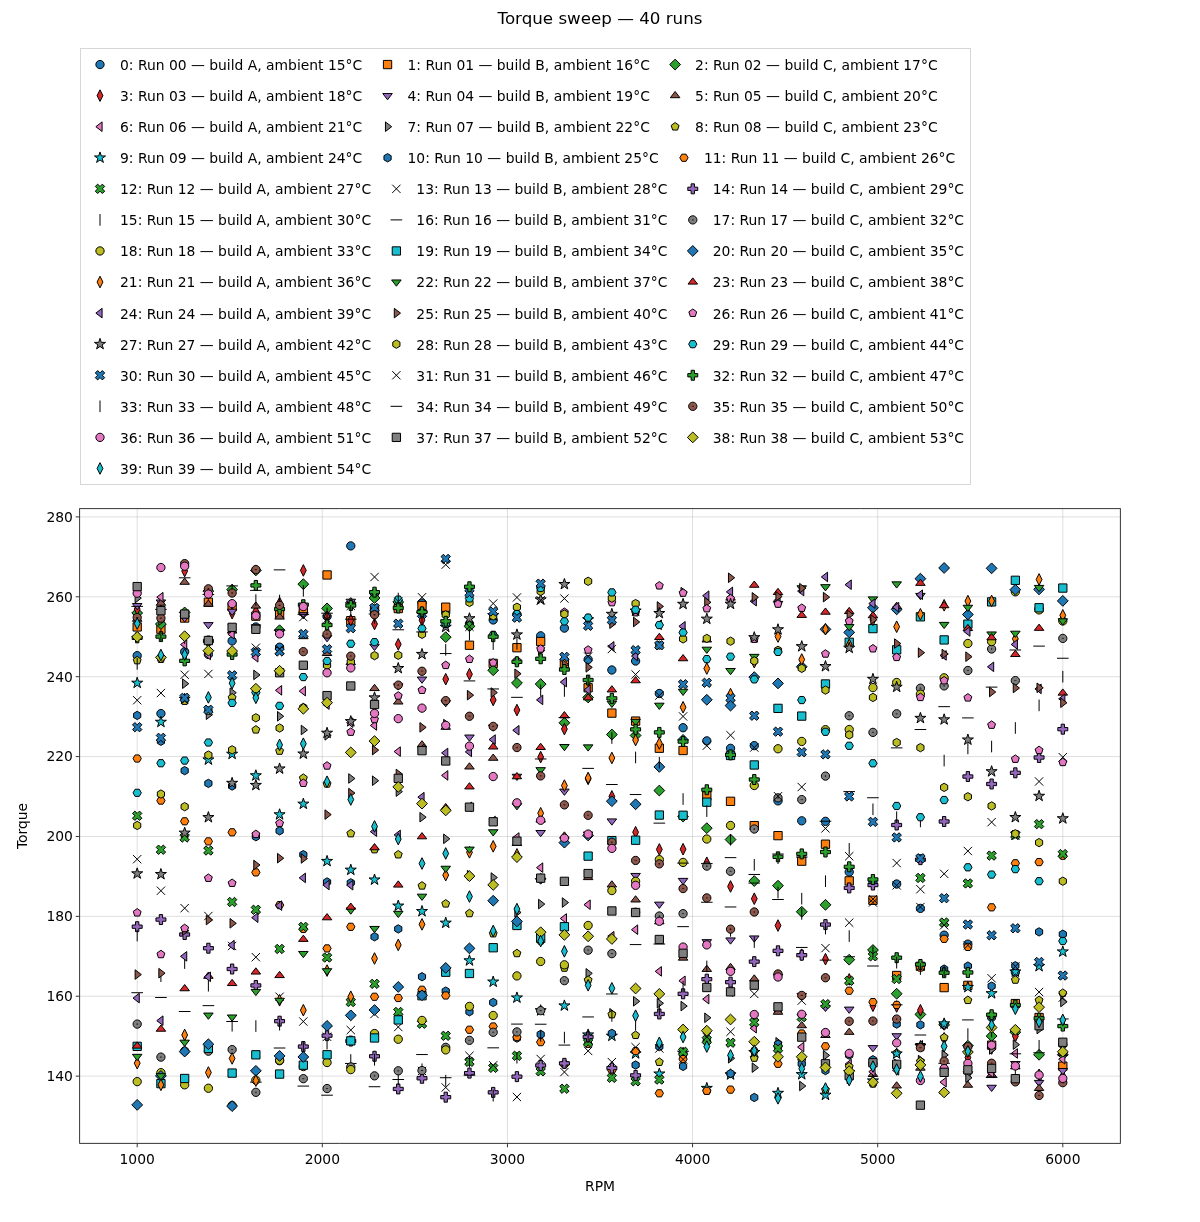

In [5]:
full = out_dir / 'full_legend.png'
nb.save_png(full, scale=1)    # scale=1 keeps this notebook small; the default is 3
show_png(full)

Saving works on a copy, so the plot on screen (`nb.last_fig`) is untouched: same
height, legend cap still unset.

In [6]:
layout(nb.last_fig)

{'figure height': 800,
 'top margin': 86,
 'bottom margin': 80,
 'plot area height': 634,
 'legend cap': None}

---
## 3. Legend on the right

A 40-entry legend on the right is much taller than the plot, so on screen it
scrolls (hover over it and use the mouse wheel).

In [7]:
nb.plot(x='RPM', y='Torque', legend='right', suptitle='Torque sweep — legend on the right')

In the image, the figure grows at the bottom by however much the legend outruns
the plot. The plot area stays put and the legend continues past its bottom edge.

Plot saved to /tmp/unichart_legend_demo_36p0c5g0/full_legend_right.png (session embedded: 40 set(s) (0 file-referenced, 40 embedded))
full_legend_right.png: 1200 x 1385 px


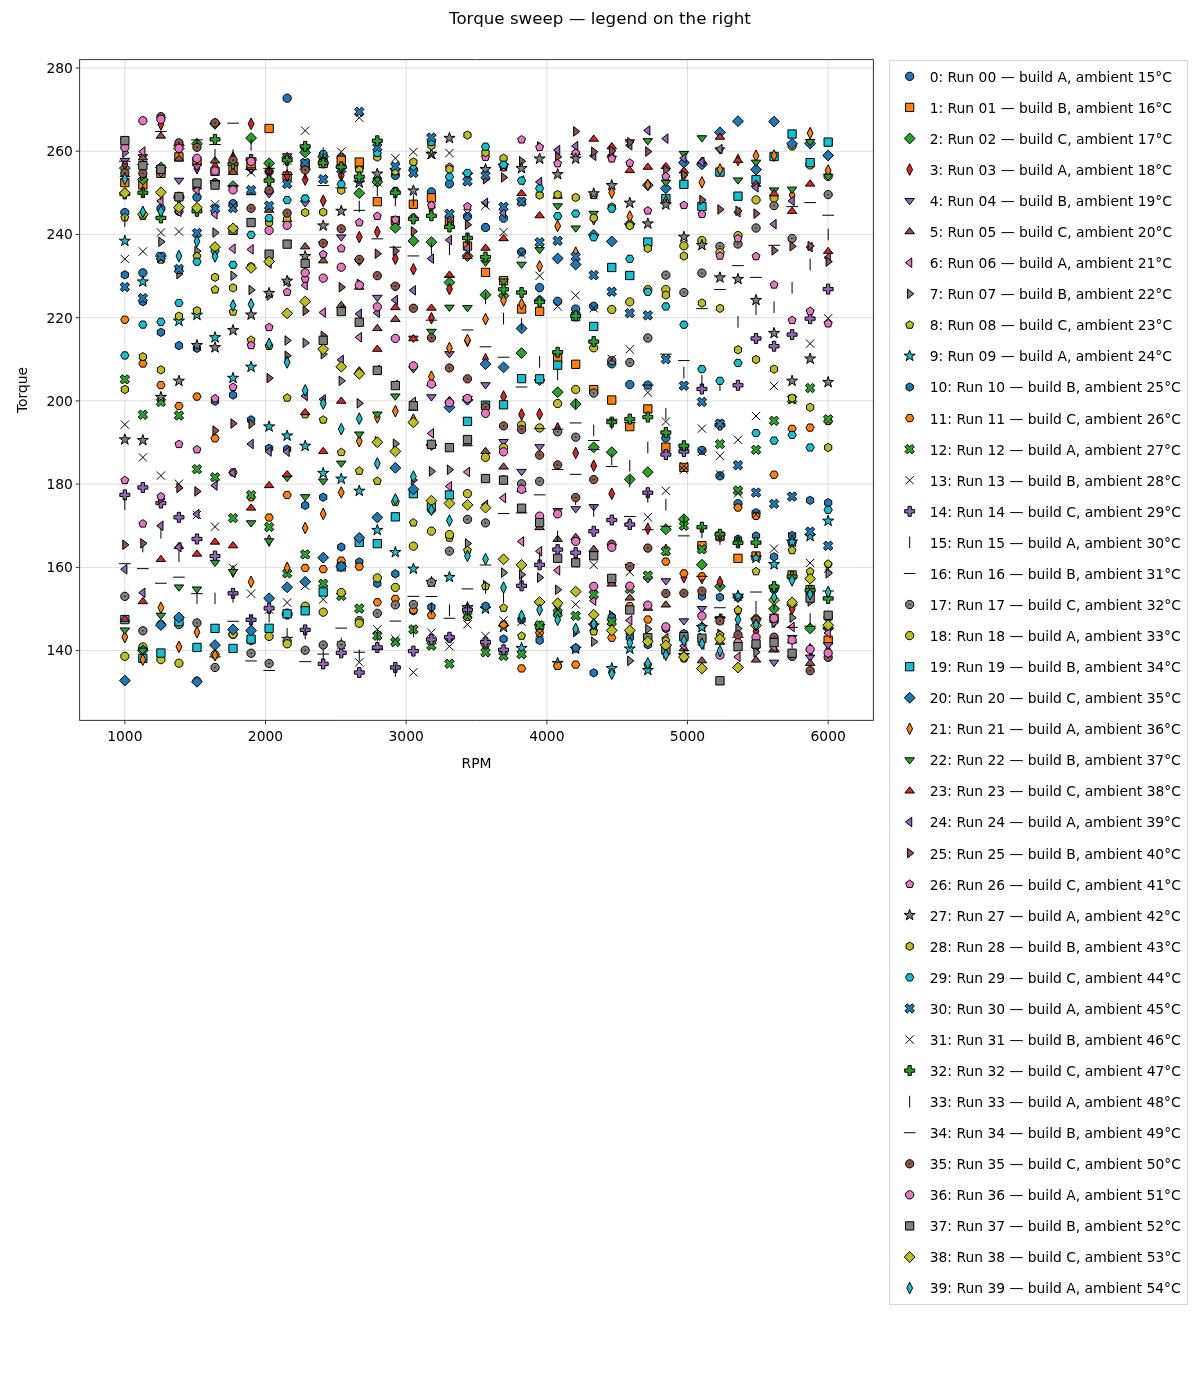

In [8]:
right = out_dir / 'full_legend_right.png'
nb.save_png(right, scale=1)
show_png(right, width=650)

---
## 4. Grouped legends (`plot_ymult`)

`plot_ymult` groups each run's variables under a title, so the legend becomes
columns of groups. Those are fitted the same way.

Plot saved to /tmp/unichart_legend_demo_36p0c5g0/full_legend_ymult.png (session embedded: 40 set(s) (0 file-referenced, 40 embedded))
full_legend_ymult.png: 1200 x 1520 px


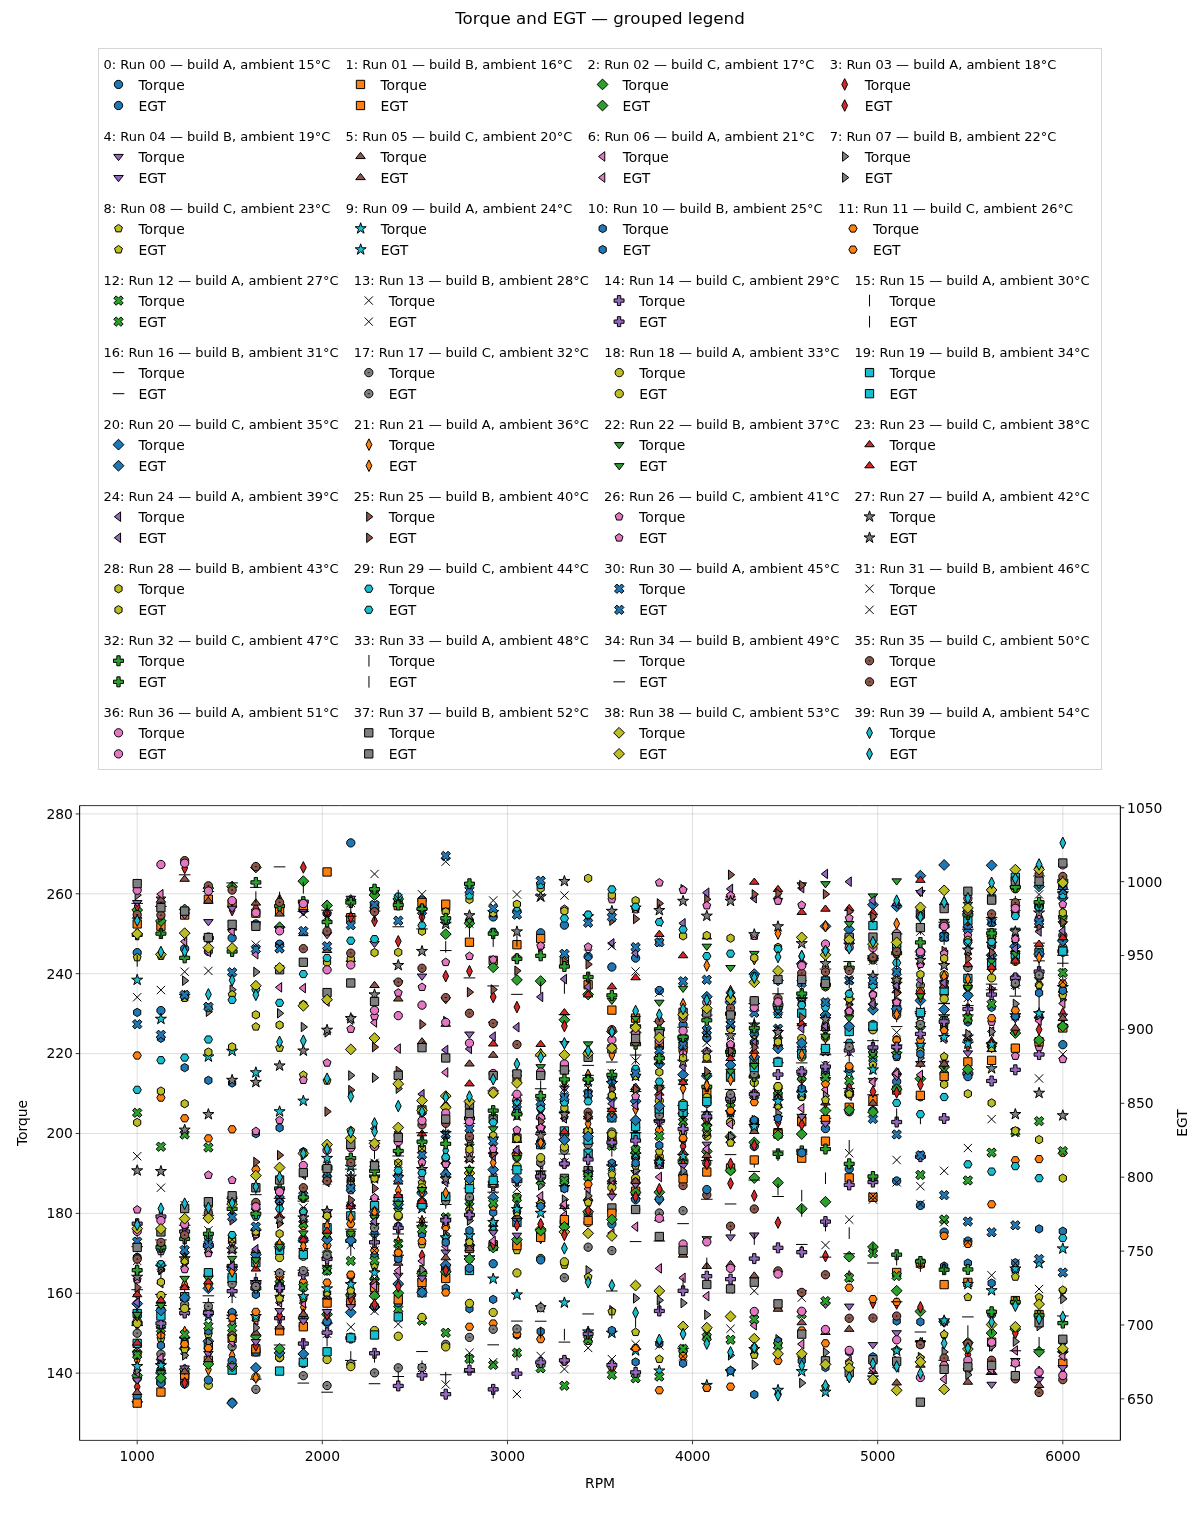

In [9]:
nb.plot_ymult(x='RPM', y=['Torque', 'EGT'], suptitle='Torque and EGT — grouped legend')
ymult = out_dir / 'full_legend_ymult.png'
nb.save_png(ymult, scale=1)
show_png(ymult)

---
## 5. A legend that already fits is left alone

With three runs there's nothing to fix: the image is exactly the figure's size.

Plot saved to /tmp/unichart_legend_demo_36p0c5g0/three_runs.png (session embedded: 3 set(s) (0 file-referenced, 3 embedded))
figure: 1200 x 800 px
three_runs.png: 1200 x 800 px


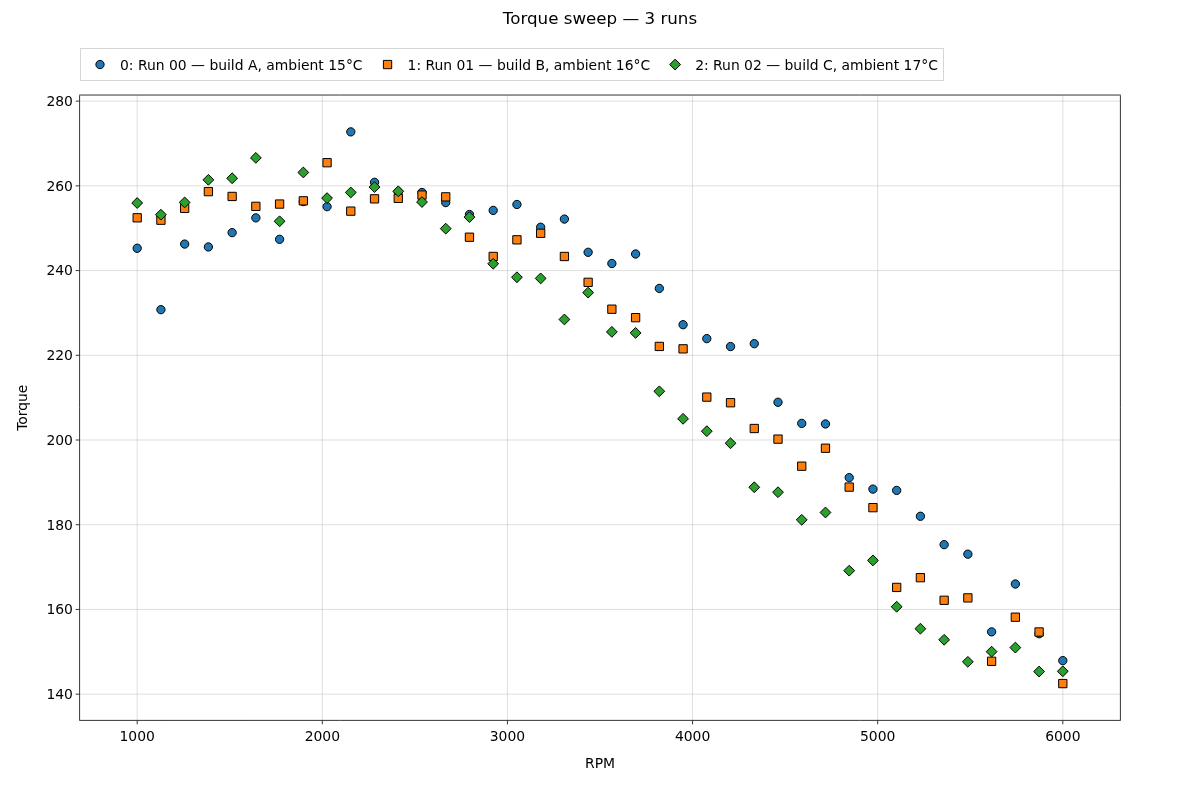

In [10]:
small = notebook_with(3)
small.plot(x='RPM', y='Torque', suptitle='Torque sweep — 3 runs')
small_png = out_dir / 'three_runs.png'
small.save_png(small_png, scale=1)
print('figure:', small.last_fig.layout.width, 'x', small.last_fig.layout.height, 'px')
show_png(small_png)

---
## 6. Static-image mode

`set_static_images()` returns every plot as a PNG instead of an interactive figure.
Those images always show the whole legend too.

Static images on (scale=1).


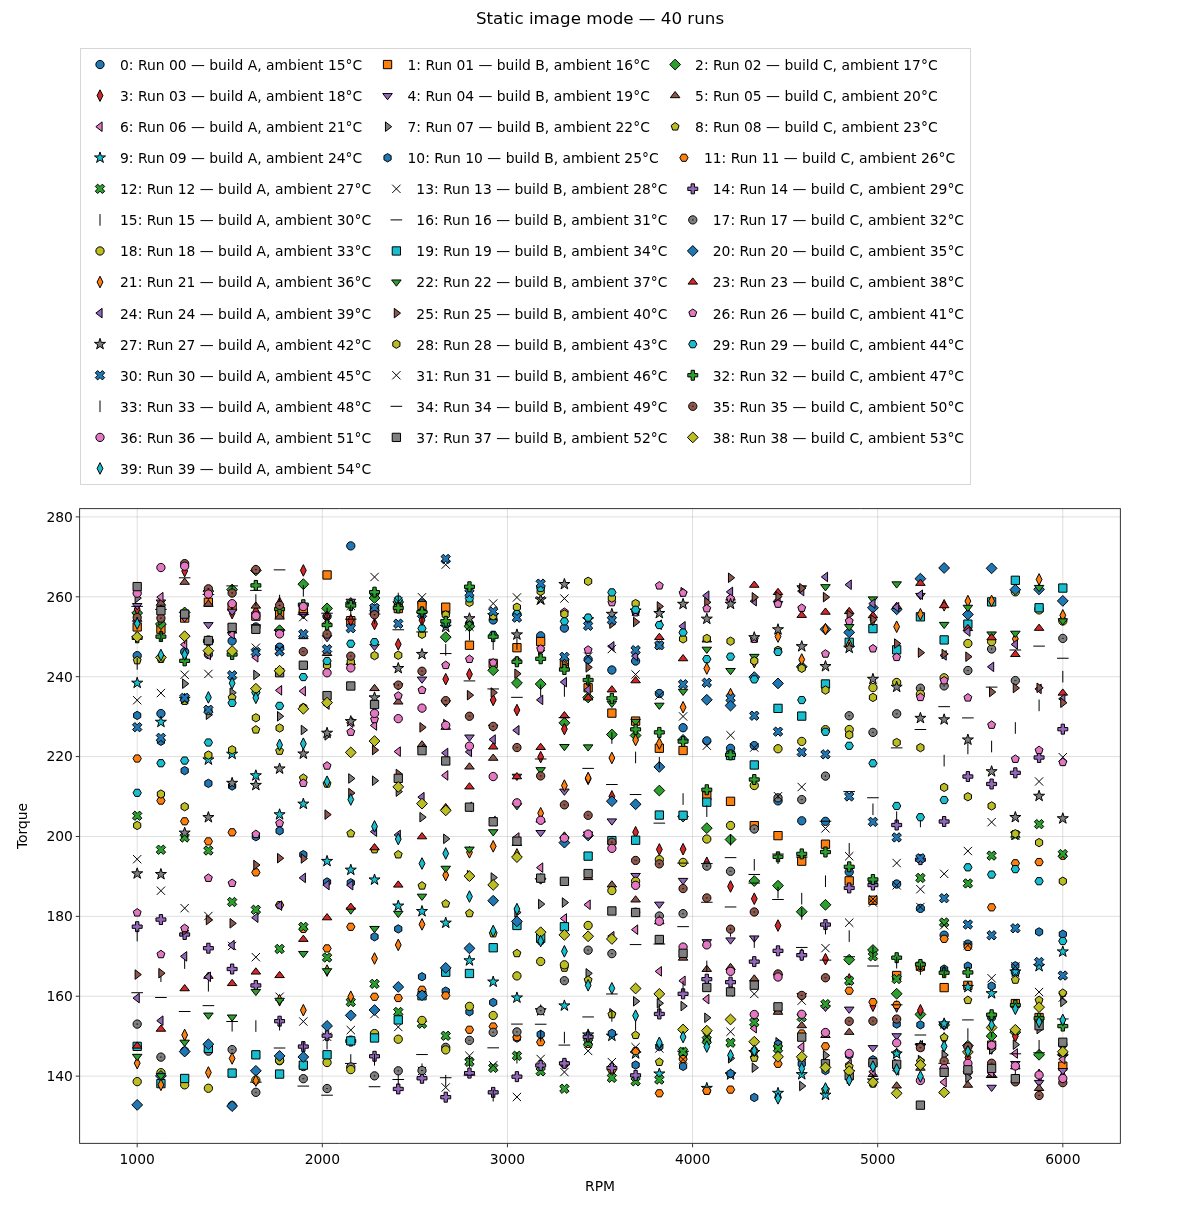

In [11]:
nb.set_static_images(scale=1)
nb.plot(x='RPM', y='Torque', suptitle='Static image mode — 40 runs')

In [12]:
nb.set_static_images(False)

Static images off (scale=1).


---
## 7. Interactive plots: `legend_scroll=False`

Interactive legends keep scrolling by default. To show the whole legend on screen
as well, turn scrolling off. Every later plot then grows to fit its legend, just
like the images.

In [13]:
nb.set_default_format(legend_scroll=False)
nb.plot(x='RPM', y='Torque', suptitle='Interactive, legend_scroll=False — 40 runs')

The plot area is the same as the three-run plot's. Only the figure height changed,
all of it in the top margin that holds the legend.

In [14]:
forty = layout(nb.last_fig)
small.set_default_format(legend_scroll=False)
small.plot(x='RPM', y='Torque')
pd.DataFrame({'3 runs': layout(small.last_fig), '40 runs': forty})

,3 runs,40 runs
figure height,800,1223
top margin,86,509
bottom margin,80,80
plot area height,634,634
legend cap,100000,100000


---
## 8. Together with `set_plot_size`

A pinned plot area survives the fit: here the plot is pinned to 8 × 3.5 in
(800 × 350 px) and the right-hand legend makes the figure much taller than that.

In [15]:
nb.set_plot_size(8, 3.5)
nb.plot(x='RPM', y='Torque', legend='right', suptitle='Pinned 8 × 3.5 in plot area, full legend')

In [16]:
layout(nb.last_fig)

{'figure height': 1385,
 'top margin': 60,
 'bottom margin': 975,
 'plot area height': 350,
 'legend cap': 100000}

Turn both settings back off:

In [17]:
nb.set_plot_size(reset=True)
nb.set_default_format(legend_scroll=True)

---
## Notes

- **An explicit `height`** passed to `save_png(height=...)` wins over the fitted height,
  so it can clip the legend again.
- **The '⧉ copy' button** copies the plot as it's displayed, so it includes the whole
  legend only with `legend_scroll=False`.
- **Dashboard panels** keep scrolling legends whatever `legend_scroll` says: their cards
  have a fixed size, and a figure grown to fit its legend would crush the plot.
- **`legend_scroll` is saved** with `save_session` and cleared by
  `set_default_format(reset=True)`.

In [18]:
shutil.rmtree(out_dir)    # the images above are already embedded in the notebook